In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv("data/all_participants_summary.csv")
df.head()

,participant,task,input_mode,label,duration,modifier
0,V1,1,standard_input,task_1a,0.982,NaN
1,V1,1,voice_control,task_1b,17.858,NaN
2,V1,1,plugin,task_1c,3.554,NaN
3,V1,2,standard_input,task_2a,1.566,NaN
4,V1,2,voice_control,task_2b,28.003,NaN


In [34]:
TASK_NAME_MAP = {
    1: "Task 1: Selecting object",
    2: "Task 2: Zooming to object",
    3: "Task 3: Alignment positioning",
    4: "Task 4: Freehand resizing one edge",
    5: "Task 5: Freehand resizing two edges",
}

INPUT_MODE_DISPLAY = {
    "standard_input": "standard",
    "plugin": "plugin",
    "voice_control": "voice control",
}

df["task_name"] = df["task"].map(TASK_NAME_MAP)
df["input_type"] = df["input_mode"].map(INPUT_MODE_DISPLAY)

# Fixed row/column order so every table below displays consistently
ROW_ORDER = list(TASK_NAME_MAP.values())
COLUMN_ORDER = ["standard", "plugin", "voice control"]


In [35]:
def make_pivot(data, aggfunc):
    pivot = data.pivot_table(
        index="task_name",
        columns="input_type",
        values="duration",
        aggfunc=aggfunc,
    )
    return pivot.reindex(index=ROW_ORDER, columns=COLUMN_ORDER).round(2)

# Mean Task Duration

In [36]:
mean_table = make_pivot(df, "mean")
mean_table

input_type,standard,plugin,voice control
task_name,,,
Task 1: Selecting object,0.89,4.82,14.18
Task 2: Zooming to object,1.97,4.99,48.59
Task 3: Alignment positioning,3.11,5.59,53.20
Task 4: Freehand resizing one edge,4.37,33.67,66.92
Task 5: Freehand resizing two edges,3.43,73.15,50.14


# Fastest Quartile Mean

In [37]:
def fastest_quartile_mean(group):
    threshold = group.quantile(0.25)
    fastest = group[group <= threshold]
    return fastest.mean()

quartile_series = df.groupby(["task_name", "input_type"])["duration"].apply(fastest_quartile_mean)
quartile_table = quartile_series.unstack("input_type").reindex(index=ROW_ORDER, columns=COLUMN_ORDER).round(2)
quartile_table

input_type,standard,plugin,voice control
task_name,,,
Task 1: Selecting object,0.70,3.03,11.33
Task 2: Zooming to object,0.96,2.92,24.29
Task 3: Alignment positioning,2.18,3.96,23.97
Task 4: Freehand resizing one edge,3.19,8.50,44.53
Task 5: Freehand resizing two edges,2.87,31.02,40.28


# Best Individual Result

In [38]:
best_table = make_pivot(df, "min")
best_table

input_type,standard,plugin,voice control
task_name,,,
Task 1: Selecting object,0.61,2.12,11.11
Task 2: Zooming to object,0.63,1.97,17.41
Task 3: Alignment positioning,1.92,2.75,17.85
Task 4: Freehand resizing one edge,2.83,5.88,34.41
Task 5: Freehand resizing two edges,2.66,22.33,37.50


# Boxplots

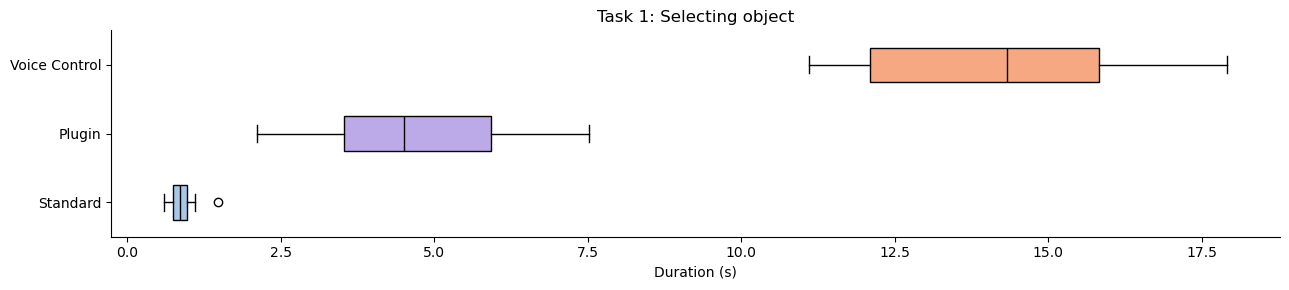

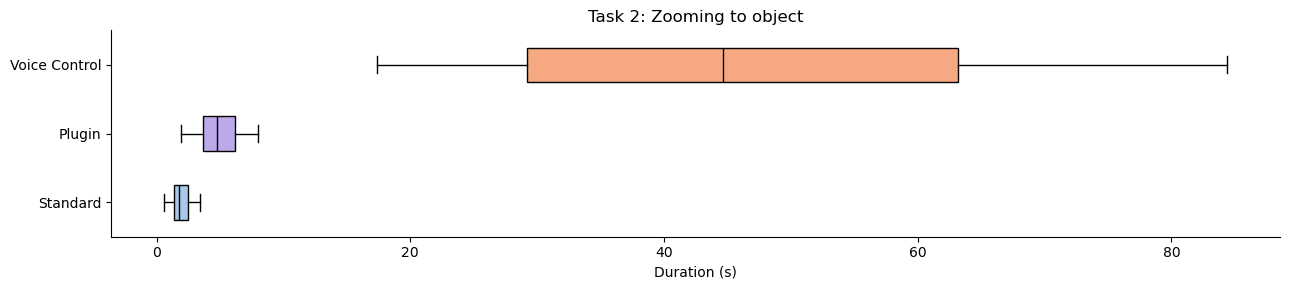

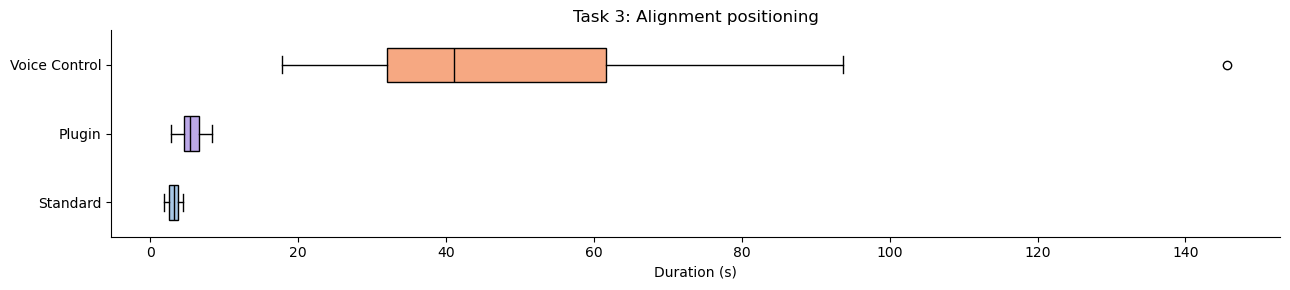

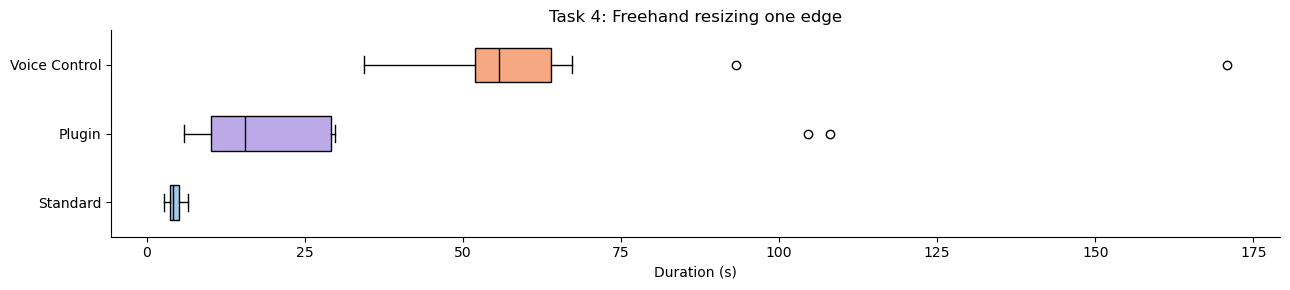

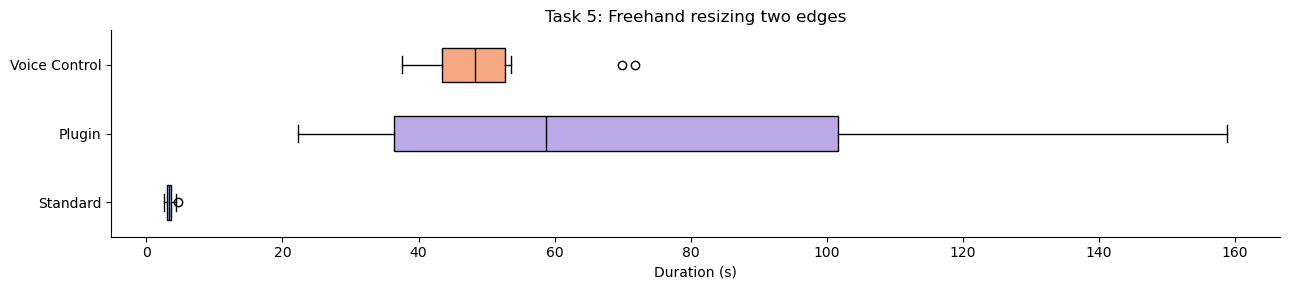

In [39]:
XTICK_LABELS = {
    "standard": "Standard",
    "plugin": "Plugin",
    "voice control": "Voice Control",
}

BOX_COLORS = {
    "standard": "#a8c8e7",
    "plugin": "#bca9e8",
    "voice control": "#f6a882",
}

def plot_task_boxplot(task_df, task_title):
    values_per_mode = []
    for mode in COLUMN_ORDER:
        mode_values = task_df.loc[task_df["input_type"] == mode, "duration"].values
        values_per_mode.append(mode_values)

    fig, ax = plt.subplots(figsize=(13, 3))
    boxplot_result = ax.boxplot(values_per_mode, patch_artist=True, widths=0.5, vert=False)

    for box_patch, mode in zip(boxplot_result["boxes"], COLUMN_ORDER):
        box_patch.set_facecolor(BOX_COLORS[mode])
        box_patch.set_alpha(1)
    for median_line in boxplot_result["medians"]:
        median_line.set_color("black")

    display_labels = []
    for mode in COLUMN_ORDER:
        display_labels.append(XTICK_LABELS[mode])
    ax.set_yticklabels(display_labels)
    ax.set_xlabel("Duration (s)")
    ax.set_title(task_title)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


for task_num, task_label in TASK_NAME_MAP.items():
    task_df = df[df["task"] == task_num]
    plot_task_boxplot(task_df, task_label)